# Human Eye Disease Prediction
**Dataset:** Labeled Optical Coherence Tomography (OCT) - Kaggle  
**Model:** MobileNetV3Large (Transfer Learning)  
**Classes:** CNV, DME, DRUSEN, NORMAL  
**Environment:** TensorFlow-CPU 2.21.0 | Python 3.12 | Windows

## TensorFlow Installation

In [1]:
import os
import pickle
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version :', tf.__version__)
print('Devices available  :', tf.config.list_physical_devices())

TensorFlow version : 2.21.0
Devices available  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Configuration

In [2]:
TRAIN_DIR   = 'train'
VAL_DIR     = 'val'
TEST_DIR    = 'test'

IMAGE_SIZE  = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 5
LR          = 0.0001
NUM_CLASSES = 4
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

## 2. Load Datasets

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=42,
    interpolation='bilinear',
)

print('Classes detected:', training_set.class_names)

Found 76515 files belonging to 4 classes.
Classes detected: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=42,
    interpolation='bilinear',
)

Found 21861 files belonging to 4 classes.


In [5]:
# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
training_set   = training_set.prefetch(buffer_size=AUTOTUNE)
validation_set = validation_set.prefetch(buffer_size=AUTOTUNE)

print('Datasets loaded and optimized with prefetch.')

Datasets loaded and optimized with prefetch.


## 3. Visualize Sample Images

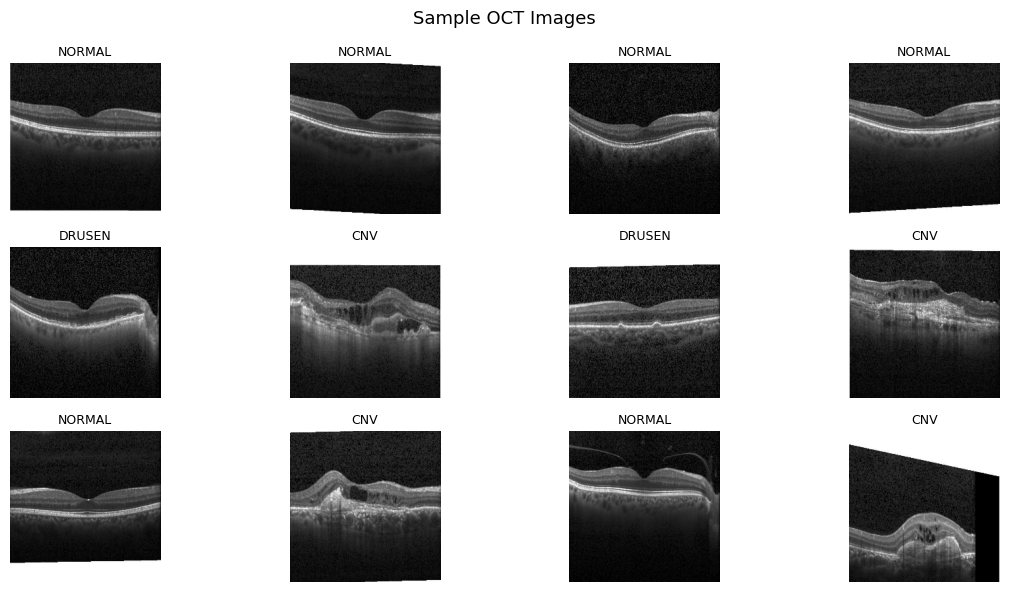

In [6]:
plt.figure(figsize=(12, 6))
for images, labels in training_set.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[tf.argmax(labels[i]).numpy()], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample OCT Images', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build Model (MobileNetV3Large + Custom Head)

In [7]:
# Load MobileNetV3Large pretrained on ImageNet (without top classifier)
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=False,          # exclude ImageNet head
    weights='imagenet',
    pooling='avg',              # global average pooling
    dropout_rate=0.2,
    include_preprocessing=True,
)

# Allow all layers to train (full fine-tuning)
base_model.trainable = True

print('Base model loaded. Trainable:', base_model.trainable)

Base model loaded. Trainable: True


In [8]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=INPUT_SHAPE),
    base_model,
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
], name='EyeDisease_MobileNetV3')

model.summary()

Model: "EyeDisease_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,247,236 (12.39 MB)

 Trainable params: 3,220,916 (12.29 MB)

 Non-trainable params: 26,320 (102.81 KB)

## 5. Compile Model

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.F1Score(average='macro', name='f1_score'),
    ],
)

print('Model compiled successfully.')

Model compiled successfully.


## 6. Callbacks

In [10]:
callbacks = [
    # Save best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        filepath='Best_Model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    # Stop early if no improvement for 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
        verbose=1,
    ),
    # Reduce learning rate on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print('Callbacks set: ModelCheckpoint | EarlyStopping | ReduceLROnPlateau')

Callbacks set: ModelCheckpoint | EarlyStopping | ReduceLROnPlateau


## 7. Train the Model
> ⏳ This will take a while depending on your CPU. Go grab a coffee! ☕

In [17]:
training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/5


KeyboardInterrupt: 

In [18]:
from tensorflow.keras.models import load_model

model = load_model("Best_Model.keras")

## 8. Save Model & History

In [19]:
model.save('Trained_Model.keras')
model.save('Trained_Model.h5')
print('Models saved: Trained_Model.keras | Trained_Model.h5')

with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)
print('Training history saved: Training_history.pkl')

Models saved: Trained_Model.keras | Trained_Model.h5


NameError: name 'training_history' is not defined

## 9. Plot Training Curves

In [20]:
# Reload history from pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)

epochs_range = range(1, len(load_history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, load_history['loss'],     color='red',  label='Train Loss')
axes[0].plot(epochs_range, load_history['val_loss'], color='blue', label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, load_history['accuracy'],     color='red',  label='Train Accuracy')
axes[1].plot(epochs_range, load_history['val_accuracy'], color='blue', label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Human Eye Disease Prediction - Training Results', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved: training_curves.png')

EOFError: Ran out of input

## 10. Load Test Set & Evaluate

In [21]:
test_set = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=64,
    image_size=IMAGE_SIZE,
    shuffle=False,       # keep order for confusion matrix
    interpolation='bilinear',
)

Found 10933 files belonging to 4 classes.


In [22]:
# Load the best saved model
best_model = tf.keras.models.load_model('Best_Model.keras')

test_loss, test_acc, test_f1 = best_model.evaluate(test_set)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1 Score : {test_f1:.4f}')

171/171 ━━━━━━━━━━━━━━━━━━━━ 158s 913ms/step - accuracy: 0.9693 - f1_score: 0.9471 - loss: 0.1032

Test Loss     : 0.1032
Test Accuracy : 0.9693
Test F1 Score : 0.9471


## 11. True vs Predicted Labels

In [19]:
# True labels
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1).numpy()

# Predicted labels
predicted_categories = best_model.predict(test_set)
Y_pred = tf.argmax(predicted_categories, axis=1).numpy()

print('True labels shape     :', Y_true.shape)
print('Predicted labels shape:', Y_pred.shape)

171/171 ━━━━━━━━━━━━━━━━━━━━ 147s 857ms/step
True labels shape     : (10933,)
Predicted labels shape: (10933,)


## 12. Classification Report

In [20]:
print(classification_report(Y_true, Y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

         CNV       0.98      0.97      0.98      3746
         DME       0.97      0.93      0.95      1161
      DRUSEN       0.86      0.90      0.88       887
      NORMAL       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.95      0.95      0.95     10933
weighted avg       0.97      0.97      0.97     10933



## 13. Confusion Matrix

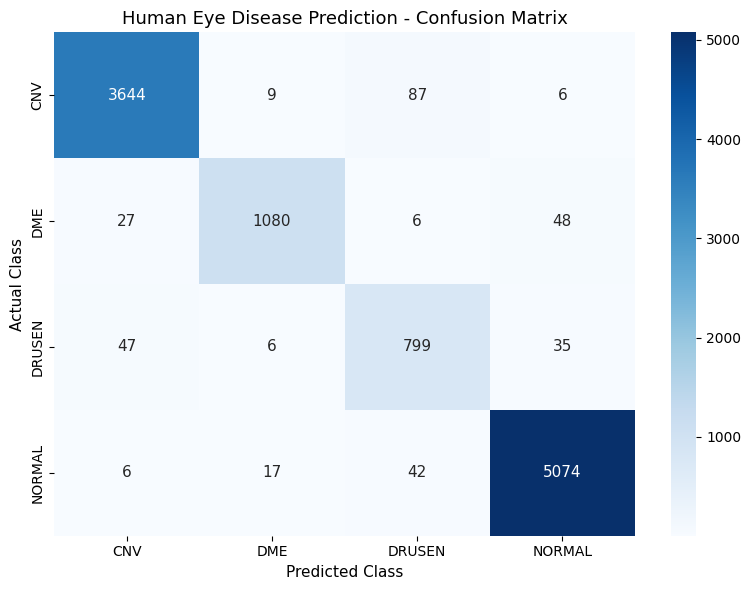

Saved: confusion_matrix.png


In [21]:
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 11},
)
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('Actual Class',    fontsize=11)
plt.title('Human Eye Disease Prediction - Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')